# Análisis de Datos

### Alumnos:

* Paola Andrea Blanco     **(a2303)**
* Facundo Manuel Quiroga  **(a2305)**
* Juan Manuel Fajardo     **(a2310)**
* Victor Gabriel Peralta  **(a2322)**
* Agustín Jesús Vazquez   **(e2301)**

## 1. Introducción al dataset y objetivos del análisis

Comprensión del Dataset
El dataset "NYPD Complaint Data Current Year To Date" contiene todas las denuncias válidas reportadas a la policía de Nueva York durante 2025. Incluye información sobre:

* Ubicación geográfica de los incidentes
* Tipo de delito
* Fecha y hora
* Demografía de víctimas y sospechosos
* Nivel de gravedad del delito

Fuente: 
* https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Current-Year-To-Date-/5uac-w243/about_data
* https://catalog.data.gov/dataset/nypd-complaint-data-current-year-to-date#:~:text=This%20dataset%20includes%20all%20valid,dictionary%20in%20the%20%E2%80%98About%E2%80%99%20section


Problema Propuesto: clasificación de nivel de gravedad de delitos
Descripción del problema:
Predecir si un delito reportado será clasificado como "Felony" (delito grave), "Misdemeanor" (delito menor) o "Violation" (violación/infracción) basándose en características del incidente.

Variable Target: LAW_CAT_CD (Law Category Code)

FELONY: Delitos graves
MISDEMEANOR: Delitos menores
VIOLATION: Infracciones

Justificación:
Este modelo permitiría a la policía:

Priorizar recursos según la gravedad esperada
Optimizar tiempos de respuesta
Mejorar la asignación de personal

## 2. Exploración y comprensión de datos (EDA) 

In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno




2.1 Carga y descripción inicial

In [3]:
# URL del dataset (CSV de NYPD Complaint Data Year-To-Date)
url = "https://data.cityofnewyork.us/api/views/5uac-w243/rows.csv?accessType=DOWNLOAD"

# Cargar los datos en un DataFrame 
df_ant = pd.read_csv(url)
df = df_ant.copy().replace(['(null)',''],None) # se genera un nuevo data frame donde se remplaza los valores que estan como (null) por none
# Información básica
print(f"Dimensiones: {df.shape}")
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")


print("Columns:", df.columns.tolist())
df.head()

#print("Shape del dataset:", df.shape)
#df.info()

Dimensiones: (438556, 36)
Número de observaciones: 438556
Número de variables: 36
Columns: ['CMPLNT_NUM', 'ADDR_PCT_CD', 'BORO_NM', 'CMPLNT_FR_DT', 'CMPLNT_FR_TM', 'CMPLNT_TO_DT', 'CMPLNT_TO_TM', 'CRM_ATPT_CPTD_CD', 'HADEVELOPT', 'HOUSING_PSA', 'JURISDICTION_CODE', 'JURIS_DESC', 'KY_CD', 'LAW_CAT_CD', 'LOC_OF_OCCUR_DESC', 'OFNS_DESC', 'PARKS_NM', 'PATROL_BORO', 'PD_CD', 'PD_DESC', 'PREM_TYP_DESC', 'RPT_DT', 'STATION_NAME', 'SUSP_AGE_GROUP', 'SUSP_RACE', 'SUSP_SEX', 'TRANSIT_DISTRICT', 'VIC_AGE_GROUP', 'VIC_RACE', 'VIC_SEX', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Lat_Lon', 'New Georeferenced Column']


,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,...,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column
0,303250435,13,MANHATTAN,03/20/2025,00:30:00,NaN,None,COMPLETED,None,NaN,...,NaN,25-44,WHITE,M,988886,207857,40.737203,-73.983273,"(40.7372030985741, -73.9832725981497)",POINT (-73.9832725981497 40.7372030985741)
1,298788022,81,BROOKLYN,01/02/2025,01:50:00,01/02/2025,03:00:00,COMPLETED,None,NaN,...,NaN,18-24,WHITE,F,1005319,190473,40.689464,-73.924029,"(40.6894642952604, -73.9240290899499)",POINT (-73.9240290899499 40.6894642952604)
2,307271594,47,BRONX,03/05/2025,17:00:00,NaN,None,COMPLETED,None,NaN,...,NaN,25-44,BLACK,F,1026480,262584,40.887314,-73.847272,"(40.8873136344706, -73.8472717577564)",POINT (-73.8472717577564 40.8873136344706)
3,306868358,9,MANHATTAN,05/22/2025,14:30:00,05/22/2025,14:45:00,COMPLETED,None,NaN,...,NaN,UNKNOWN,UNKNOWN,M,0,0,0.000000,0.000000,"(0.0, 0.0)",POINT (0 0)
4,309137838,14,MANHATTAN,07/05/2025,18:00:00,07/05/2025,18:31:00,COMPLETED,None,NaN,...,NaN,18-24,BLACK,F,0,0,0.000000,0.000000,"(0.0, 0.0)",POINT (0 0)


In [4]:

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CMPLNT_NUM,438556,438556,303250435,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADDR_PCT_CD,438556.0,NaN,NaN,NaN,63.516265,34.940599,1.0,40.0,62.0,101.0,123.0
BORO_NM,437587,5,BROOKLYN,122257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CMPLNT_FR_DT,438556,1804,05/01/2025,1881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CMPLNT_FR_TM,438556,1440,12:00:00,8793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CMPLNT_TO_DT,418228,1279,05/07/2025,1734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CMPLNT_TO_TM,418555,1440,12:00:00,5059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRM_ATPT_CPTD_CD,438556,2,COMPLETED,433073,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HADEVELOPT,1452,25,INGERSOLL,277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HOUSING_PSA,27186.0,NaN,NaN,NaN,10976.441772,21578.842193,218.0,477.0,741.0,3924.0,73862.0


Variables principales para analizar:

Temporales: CMPLNT_FR_DT, CMPLNT_FR_TM, CMPLNT_TO_DT, CMPLNT_TO_TM

Geográficas: BORO, ADDR_PCT_CD, Latitude, Longitude, PATROL_BORO

Tipo de delito: OFNS_DESC, PD_DESC, KY_CD, LAW_CAT_CD

Demográficas: VIC_AGE_GROUP, VIC_RACE, VIC_SEX, SUSP_AGE_GROUP, SUSP_RACE, SUSP_SEX

Ubicación específica: PREM_TYP_DESC (tipo de local, por ejemplo tienda, calle, vivienda... etc)

Estado: CRM_ATPT_CPTD_CD (completado/intentado)



## 2.2 Distribución de la variable target LAW_CAT_CD

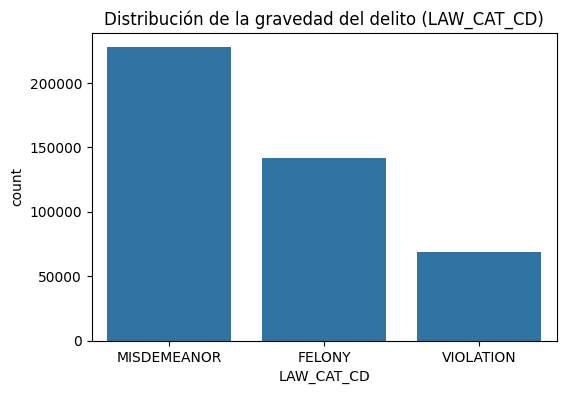

LAW_CAT_CD
MISDEMEANOR    0.519149
FELONY         0.323826
VIOLATION      0.157024
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['LAW_CAT_CD'], order=df['LAW_CAT_CD'].value_counts().index)
plt.title("Distribución de la gravedad del delito (LAW_CAT_CD)")
plt.show()


target_dist = df['LAW_CAT_CD'].value_counts(normalize=True)
#target_dist = df['LAW_CAT_CD'].value_counts(normalize=False)
print(target_dist)


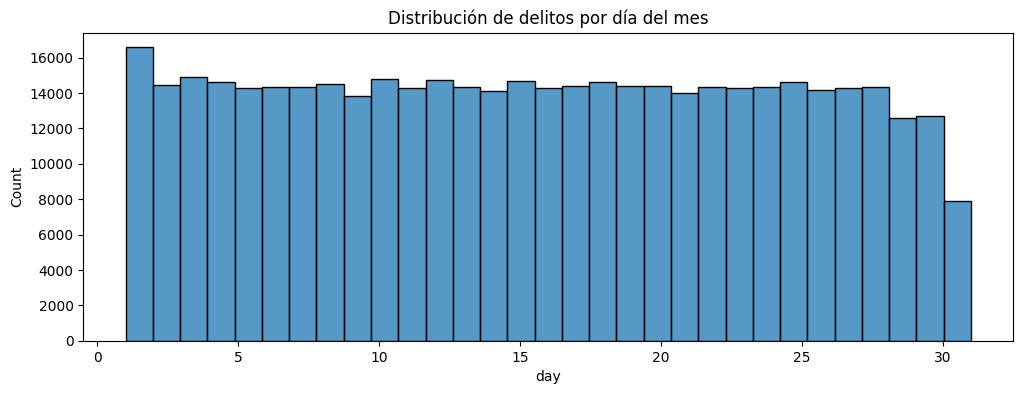

In [6]:
df['CMPLNT_FR_DT'] = pd.to_datetime(df['CMPLNT_FR_DT'],errors='coerce')
df['day'] = df['CMPLNT_FR_DT'].dt.day

plt.figure(figsize=(12,4))
sns.histplot(df['day'], bins=31)
plt.title("Distribución de delitos por día del mes")
plt.show()


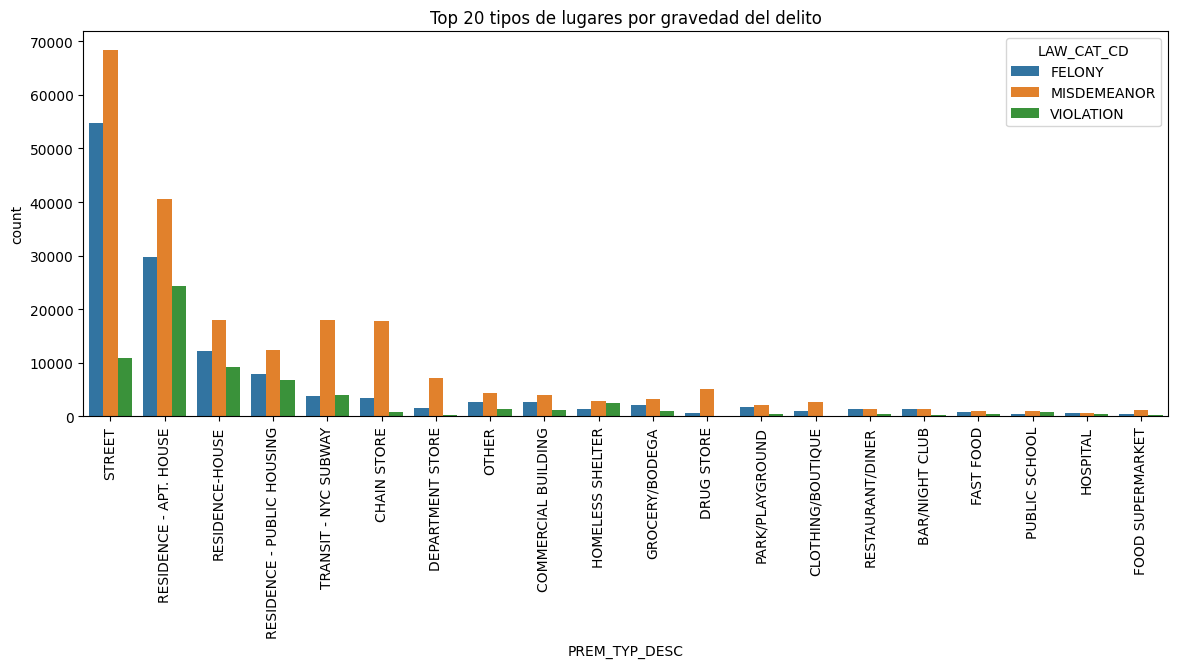

In [7]:
plt.figure(figsize=(14,5))
sns.countplot(data=df, x='PREM_TYP_DESC', hue='LAW_CAT_CD', order=df['PREM_TYP_DESC'].value_counts().index[:20])
plt.xticks(rotation=90)
plt.title("Top 20 tipos de lugares por gravedad del delito")
plt.show()


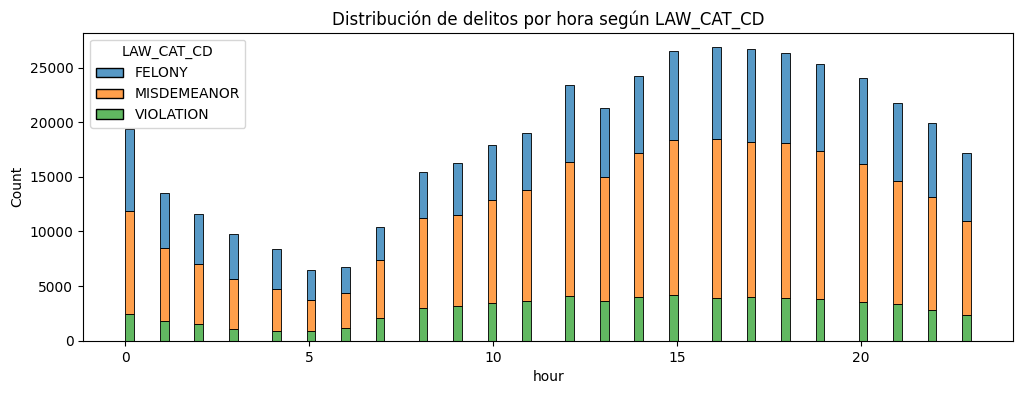

In [8]:
df['hour'] = pd.to_datetime(df['CMPLNT_FR_TM'], format="%H:%M:%S").dt.hour

plt.figure(figsize=(12,4))
sns.histplot(data=df, x='hour', hue='LAW_CAT_CD', multiple='stack')
plt.title("Distribución de delitos por hora según LAW_CAT_CD")
plt.show()


## PLANTEO DEL PROBLEMA DE ML SUPERVISADO

El dataset contiene variables que describen características de una denuncia policial y queremos predecir su gravedad legal.

 Problema: Clasificación multiclase
 Clases: FELONY, MISDEMEANOR, VIOLATION
 Enfoque: Modelos clasificadores

## 2.3 Valores faltantes

<Figure size 1200x600 with 0 Axes>

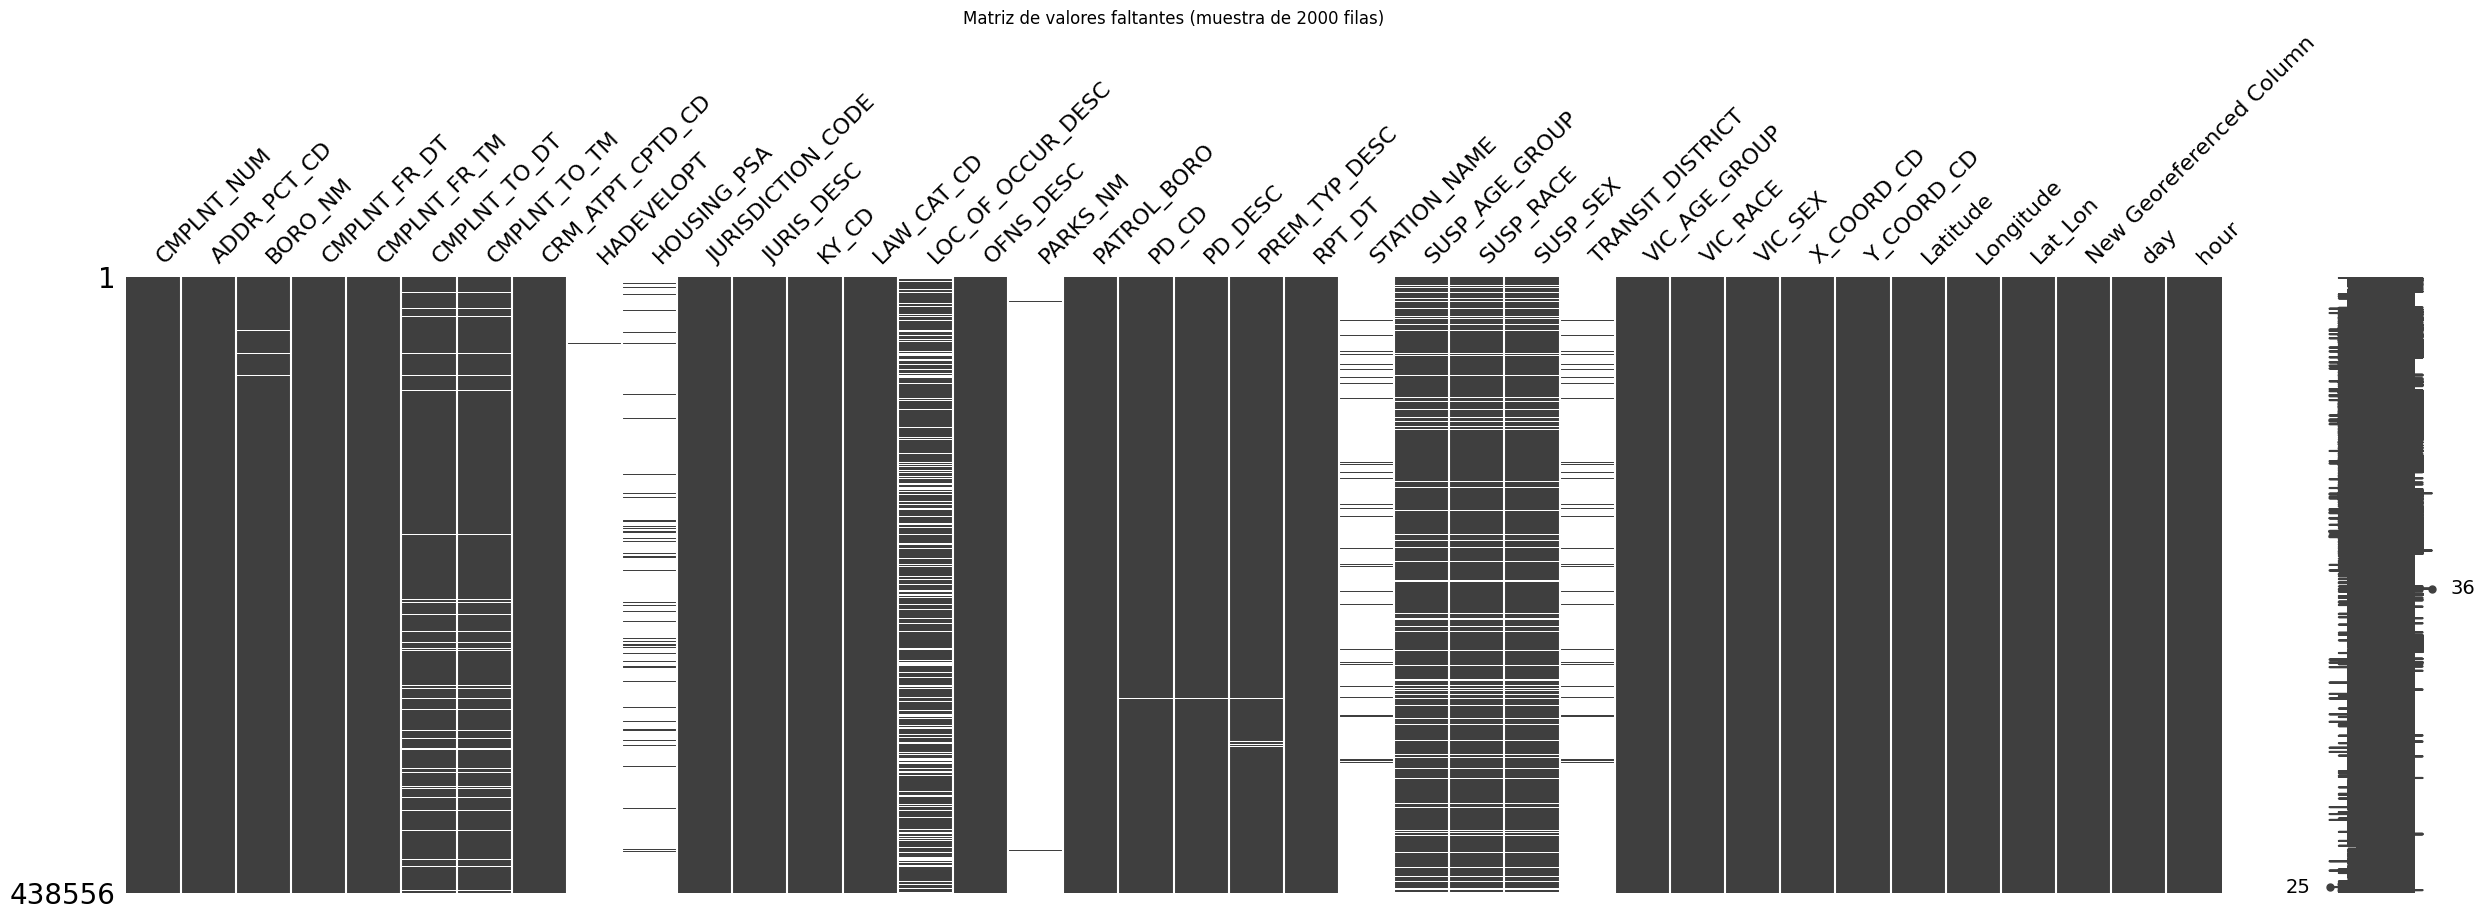

HADEVELOPT           0.996689
PARKS_NM             0.993946
STATION_NAME         0.940126
TRANSIT_DISTRICT     0.940126
HOUSING_PSA          0.938010
LOC_OF_OCCUR_DESC    0.226949
SUSP_SEX             0.100306
SUSP_RACE            0.100306
SUSP_AGE_GROUP       0.100306
CMPLNT_TO_DT         0.046352
CMPLNT_TO_TM         0.045606
PREM_TYP_DESC        0.003049
BORO_NM              0.002210
PD_CD                0.000554
PD_DESC              0.000554
VIC_RACE             0.000292
OFNS_DESC            0.000018
CMPLNT_FR_DT         0.000011
day                  0.000011
PATROL_BORO          0.000007
dtype: float64

In [9]:
plt.figure(figsize=(12,6))
#msno.matrix(df.sample(2000))
msno.matrix(df, figsize=(30,8))
plt.title("Matriz de valores faltantes (muestra de 2000 filas)")
plt.show()

na_ratio = df.isna().mean().sort_values(ascending=False)
na_ratio.head(20)



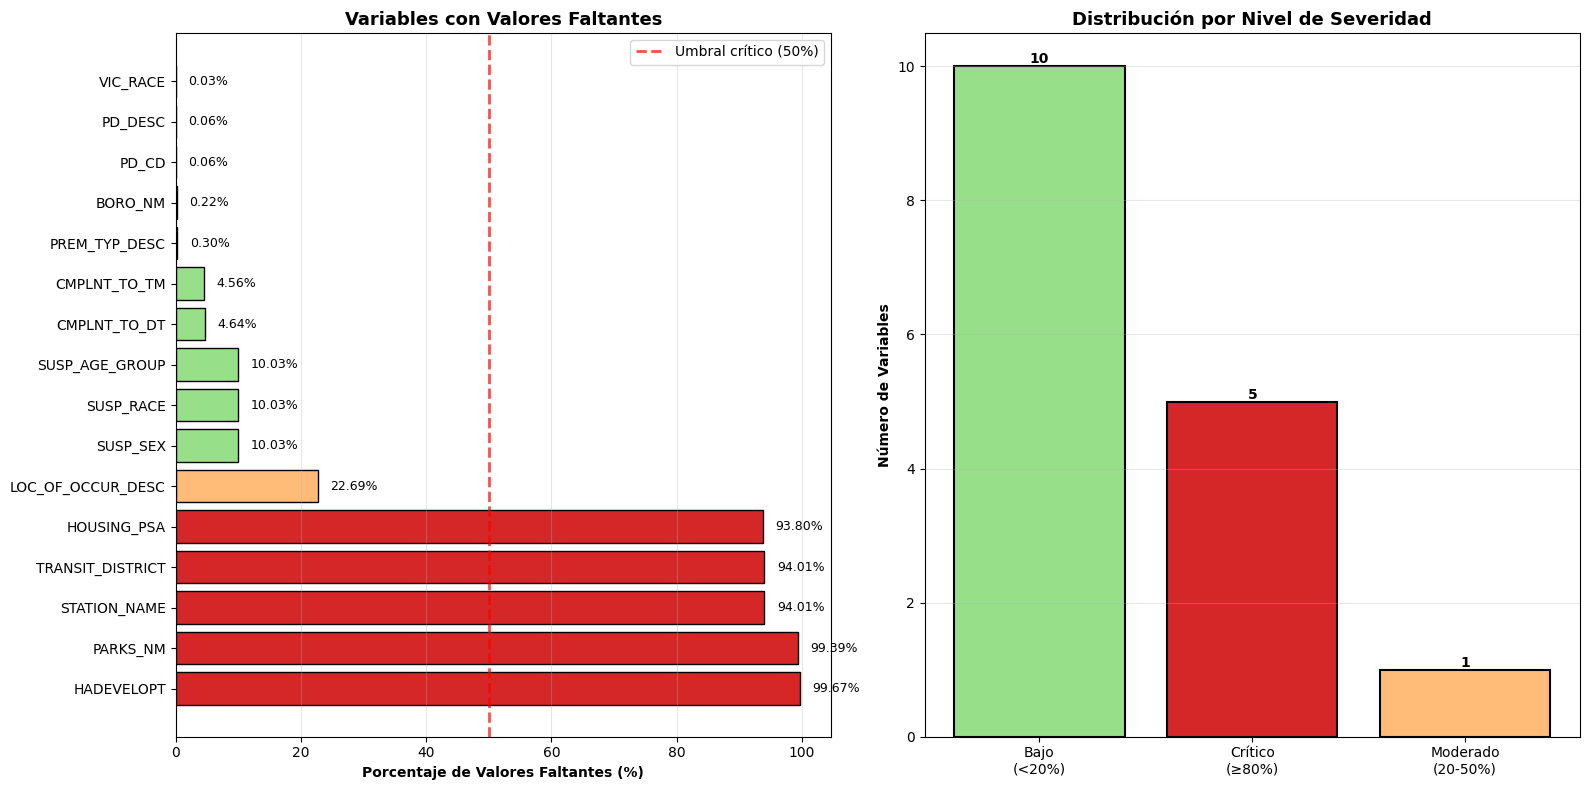


RESUMEN DE VALORES FALTANTES
Total de variables: 38
Variables con faltantes: 16
Variables sin faltantes: 22

Por severidad:
categoria
Bajo\n(<20%)          10
Crítico\n(≥80%)        5
Moderado\n(20-50%)     1


In [10]:
df_missing = df.isna().mean().sort_values(ascending=False)
df_missing.head(20)

# 1. Calcular valores faltantes
df_missing = df.isna().mean().sort_values(ascending=False)
df_missing_pct = (df_missing * 100).round(2)

# 2. Crear DataFrame
df_missing_plot = pd.DataFrame({
    'columna': df_missing_pct.index,
    'porcentaje': df_missing_pct.values
})

# 3. Filtrar solo con faltantes
df_missing_plot = df_missing_plot[df_missing_plot['porcentaje'] > 0]

# 4. Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# SUBPLOT 1: Barras horizontales (Top 15)
top20 = df_missing_plot.head(20)
colors = ['#d62728' if x >= 80 else '#ff7f0e' if x >= 50 else '#ffbb78' if x >= 20 else '#98df8a' 
          for x in top20['porcentaje']]

ax1.barh(top20['columna'], top20['porcentaje'], color=colors, edgecolor='black')
ax1.set_xlabel('Porcentaje de Valores Faltantes (%)', fontweight='bold')
ax1.set_title('Variables con Valores Faltantes', fontweight='bold', fontsize=13)
ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Umbral crítico (50%)')
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

for i, val in enumerate(top20['porcentaje']):
    ax1.text(val + 2, i, f'{val:.2f}%', va='center', fontsize=9)

# SUBPLOT 2: Conteo por categoría
def categorizar(val):
    if val >= 80: return 'Crítico\n(≥80%)'
    elif val >= 50: return 'Alto\n(50-80%)'
    elif val >= 20: return 'Moderado\n(20-50%)'
    else: return 'Bajo\n(<20%)'

df_missing_plot['categoria'] = df_missing_plot['porcentaje'].apply(categorizar)
conteo = df_missing_plot['categoria'].value_counts()

colors_cat = {'Crítico\n(≥80%)': '#d62728', 'Alto\n(50-80%)': '#ff7f0e',
              'Moderado\n(20-50%)': '#ffbb78', 'Bajo\n(<20%)': '#98df8a'}

bars = ax2.bar(range(len(conteo)), conteo.values, 
               color=[colors_cat[x] for x in conteo.index],
               edgecolor='black', linewidth=1.5)

ax2.set_xticks(range(len(conteo)))
ax2.set_xticklabels(conteo.index, fontsize=10)
ax2.set_ylabel('Número de Variables', fontweight='bold')
ax2.set_title('Distribución por Nivel de Severidad', fontweight='bold', fontsize=13)
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_valores_faltantes.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Imprimir resumen
print("\n" + "="*60)
print("RESUMEN DE VALORES FALTANTES")
print("="*60)
print(f"Total de variables: {len(df.columns)}")
print(f"Variables con faltantes: {len(df_missing_plot)}")
print(f"Variables sin faltantes: {len(df.columns) - len(df_missing_plot)}")
print("\nPor severidad:")
print(df_missing_plot['categoria'].value_counts().to_string())
print("="*60)


## 2.4 Clasificación de los faltantes

FALTANTES MASIVOS (>90%) — HADEVELOPT, PARKS_NM, STATION_NAME, TRANSIT_DISTRICT, HOUSING_PSA

**Tipo de faltante: MCAR / parcialmente MAR**

Son columnas altamente incompletas (más del 90% NA), no están presentes en la mayoría de registros
No tienen relación directa con la gravedad del delito. No aportan información útil al target LAW_CAT_CD

**Metodología aplicada: eliminación de columnas**

Con mas del 90% NA no pueden imputarse (se vuelve ruido).
Transformación o segmentación no sirven porque casi no hay datos.
No son predictivas para la gravedad del delito.
Eliminarlas mejora la calidad del dataset sin perder información relevante.

FALTANTES MEDIOS (20–30%) — LOC_OF_OCCUR_DESC
**Tipo de faltante: MAR**

Dependiente del tipo de crimen: algunos delitos no registran dónde ocurrió (delitos ciberneticos?)
Otros sí (robos, agresiones).

**Metodología aplicada: Segmentación ("UNKNOWN")**

Esta variable aporta valor al target (LAW_CAT_CD):

Felony (delitos graves) tiene más detalle de lugar que misdemeanors. Si eliminamos el 22% de filas dañaría al modelo y si imputamos la moda introduciría sesgo.

FALTANTES MODERADOS (10%) — datos del sospechoso: SUSP_AGE_GROUP, SUSP_RACE, SUSP_SEX
**Tipo de faltante: MNAR / MAR**

Faltan cuando:

No hay arresto

No se identificó un sospechoso

Información restringida

**Metodología aplicada: Segmentación ("UNKNOWN")**

Eliminarlos introduce sesgo porque las filas sin sospechoso suelen ser delitos menores y esto afecta LAW_CAT_CD.

No se deben imputar porque introduce sesgo racial, etario y de género
Los faltantes tienen significado real

FALTANTES BAJOS (≈5%) — fechas y horas: CMPLNT_TO_DT , CMPLNT_TO_TM

**Tipo: MAR / MNAR**

Los denunciantes no siempre conocen la hora exacta

**Metodología aplicada: Imputación por la moda del mismo precinto (ADDR_PCT_CD)**

Las fechas suelen correlacionar con el tipo de crimen, pero el 5% faltante no amerita eliminación.
Asumir el patrón temporal del precinct es razonable y no introduce sesgo.

FALTANTES MINIMOS (<1%) — PREM_TYP_DESC, BORO_NM, PD_DESC, PD_CD, VC_RACE

**Tipo: MCAR**

Muy pocos NA (aleatorios)

**Metodología aplicada: Imputación por la moda global**


##Visualizaciones clave

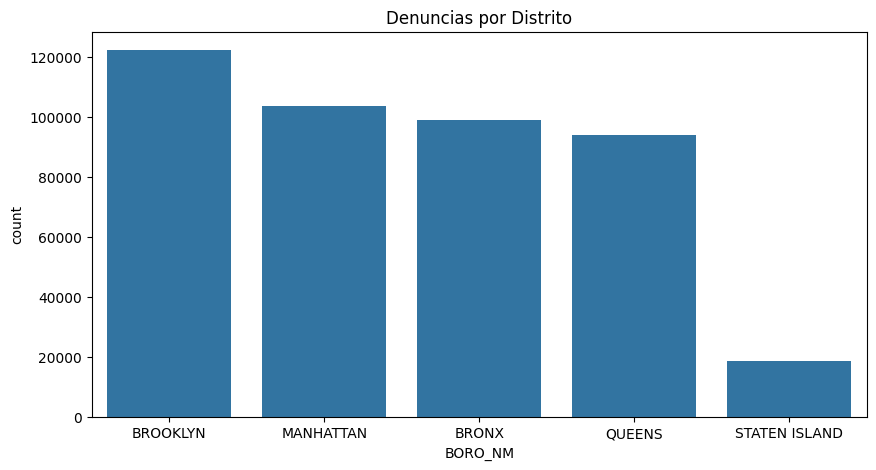

In [11]:
#Delitos por distrito 
plt.figure(figsize=(10,5))
sns.countplot(x=df['BORO_NM'], order=df['BORO_NM'].value_counts().index)
plt.title("Denuncias por Distrito")
plt.show()


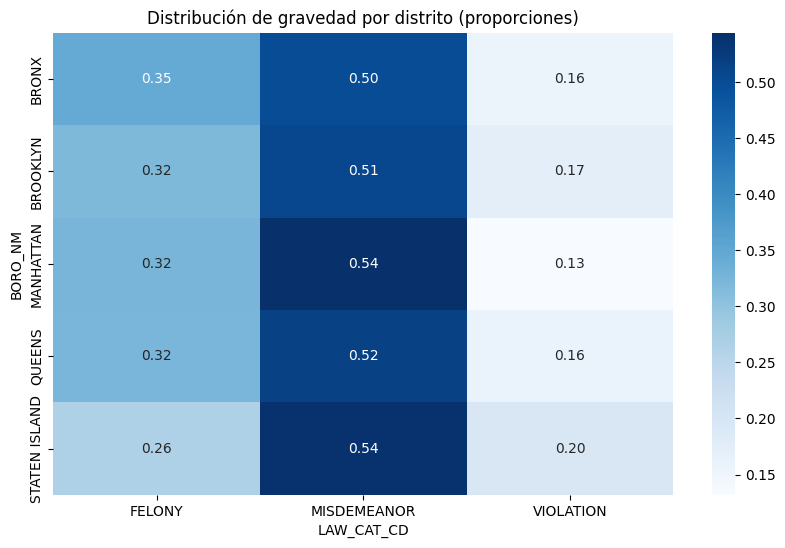

In [12]:
#Gravedad del delito por distrito

ct = pd.crosstab(df['BORO_NM'], df['LAW_CAT_CD'], normalize='index')

plt.figure(figsize=(10,6))
sns.heatmap(ct, cmap="Blues", annot=True, fmt=".2f")
plt.title("Distribución de gravedad por distrito (proporciones)")
plt.show()


C:\Users\pandr\AppData\Local\Temp\ipykernel_15888\1938501622.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CMPLNT_FR_TM'] = pd.to_datetime(df['CMPLNT_FR_TM'], errors='coerce')


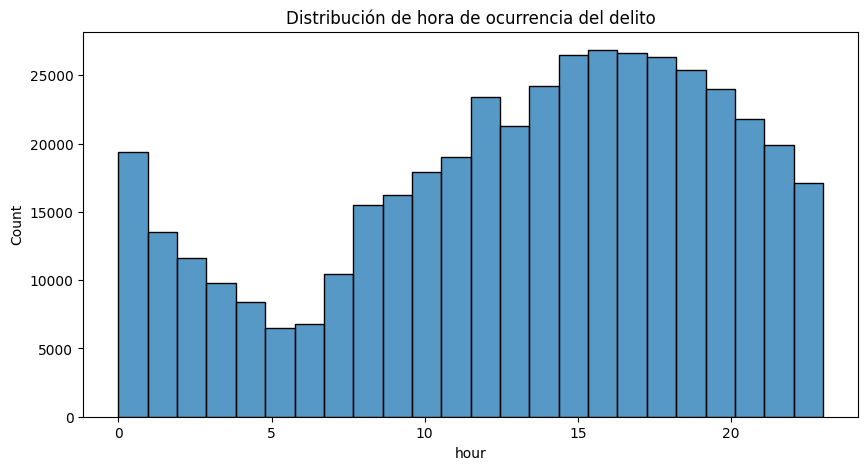

In [13]:
#Distribución por hora del día

df['CMPLNT_FR_TM'] = pd.to_datetime(df['CMPLNT_FR_TM'], errors='coerce')
df['hour'] = df['CMPLNT_FR_TM'].dt.hour

plt.figure(figsize=(10,5))
sns.histplot(df['hour'].dropna(), bins=24)
plt.title("Distribución de hora de ocurrencia del delito")
plt.show()


## PREPROCESAMIENTO Y LIMPIEZA DEL DATA SET

In [14]:
cols_drop = ["HADEVELOPT","PARKS_NM","STATION_NAME","TRANSIT_DISTRICT","HOUSING_PSA"]
df.drop(columns=cols_drop, inplace=True)


In [15]:
df['LOC_OF_OCCUR_DESC'] = df['LOC_OF_OCCUR_DESC'].fillna("UNKNOWN")


In [16]:
for c in ["SUSP_AGE_GROUP","SUSP_RACE","SUSP_SEX"]:
    df[c] = df[c].fillna("UNKNOWN")


In [17]:
for col in ['CMPLNT_TO_DT','CMPLNT_TO_TM']:
    df[col] = df.groupby('ADDR_PCT_CD')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
    )


In [18]:
df['PREM_TYP_DESC'] = df['PREM_TYP_DESC'].fillna(df['PREM_TYP_DESC'].mode()[0])


In [19]:
print("Columns:", df.columns.tolist())
df.head()

Columns: ['CMPLNT_NUM', 'ADDR_PCT_CD', 'BORO_NM', 'CMPLNT_FR_DT', 'CMPLNT_FR_TM', 'CMPLNT_TO_DT', 'CMPLNT_TO_TM', 'CRM_ATPT_CPTD_CD', 'JURISDICTION_CODE', 'JURIS_DESC', 'KY_CD', 'LAW_CAT_CD', 'LOC_OF_OCCUR_DESC', 'OFNS_DESC', 'PATROL_BORO', 'PD_CD', 'PD_DESC', 'PREM_TYP_DESC', 'RPT_DT', 'SUSP_AGE_GROUP', 'SUSP_RACE', 'SUSP_SEX', 'VIC_AGE_GROUP', 'VIC_RACE', 'VIC_SEX', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Lat_Lon', 'New Georeferenced Column', 'day', 'hour']


,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,JURISDICTION_CODE,JURIS_DESC,...,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column,day,hour
0,303250435,13,MANHATTAN,2025-03-20,2025-12-07 00:30:00,03/14/2025,12:00:00,COMPLETED,0,N.Y. POLICE DEPT,...,WHITE,M,988886,207857,40.737203,-73.983273,"(40.7372030985741, -73.9832725981497)",POINT (-73.9832725981497 40.7372030985741),20.0,0
1,298788022,81,BROOKLYN,2025-01-02,2025-12-07 01:50:00,01/02/2025,03:00:00,COMPLETED,0,N.Y. POLICE DEPT,...,WHITE,F,1005319,190473,40.689464,-73.924029,"(40.6894642952604, -73.9240290899499)",POINT (-73.9240290899499 40.6894642952604),2.0,1
2,307271594,47,BRONX,2025-03-05,2025-12-07 17:00:00,06/23/2025,08:00:00,COMPLETED,0,N.Y. POLICE DEPT,...,BLACK,F,1026480,262584,40.887314,-73.847272,"(40.8873136344706, -73.8472717577564)",POINT (-73.8472717577564 40.8873136344706),5.0,17
3,306868358,9,MANHATTAN,2025-05-22,2025-12-07 14:30:00,05/22/2025,14:45:00,COMPLETED,0,N.Y. POLICE DEPT,...,UNKNOWN,M,0,0,0.000000,0.000000,"(0.0, 0.0)",POINT (0 0),22.0,14
4,309137838,14,MANHATTAN,2025-07-05,2025-12-07 18:00:00,07/05/2025,18:31:00,COMPLETED,0,N.Y. POLICE DEPT,...,BLACK,F,0,0,0.000000,0.000000,"(0.0, 0.0)",POINT (0 0),5.0,18


## 3 Identificación de Outliers

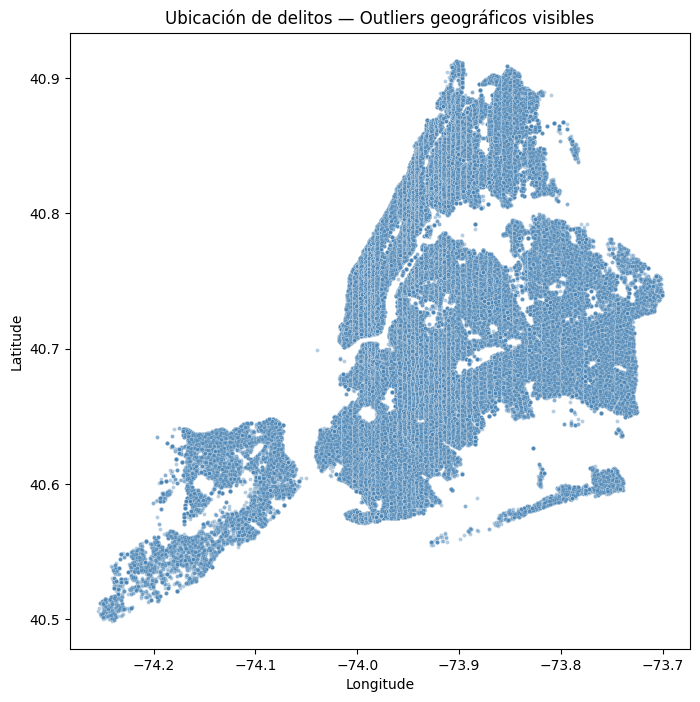

In [20]:
df = df[df['Latitude'].between(40.49, 40.92)]
df = df[df['Longitude'].between(-74.27, -73.68)]

plt.figure(figsize=(8,8))
sns.scatterplot(
    data=df, 
    x='Longitude', 
    y='Latitude',
    color='steelblue',
    s=8,
    alpha=0.4
)
plt.title("Ubicación de delitos — Outliers geográficos visibles")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



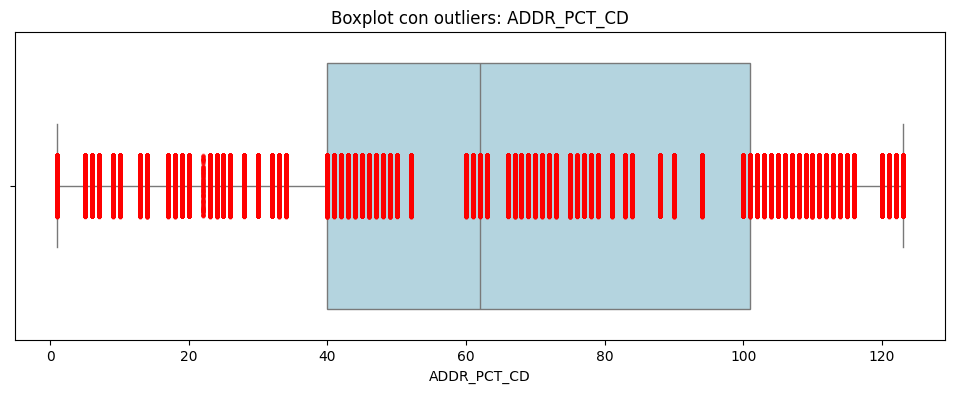

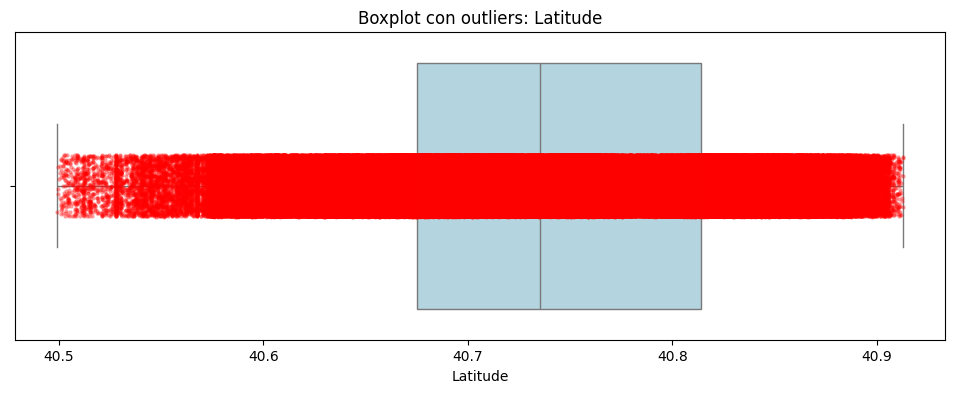

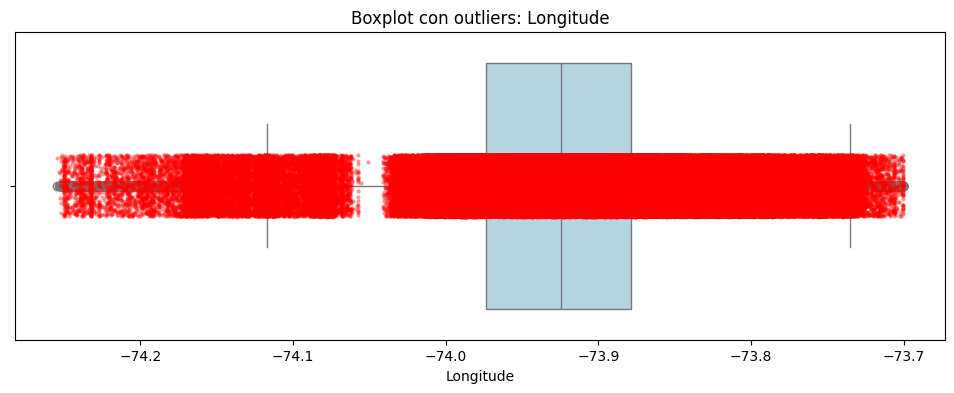

In [21]:
def boxplot_points(col):
    plt.figure(figsize=(12,4))
    sns.boxplot(x=df[col], color='lightblue')
    sns.stripplot(x=df[col], color='red', alpha=0.4, size=3)
    plt.title(f"Boxplot con outliers: {col}")
    plt.show()

for col in ['ADDR_PCT_CD', 'Latitude', 'Longitude']:
    boxplot_points(col)

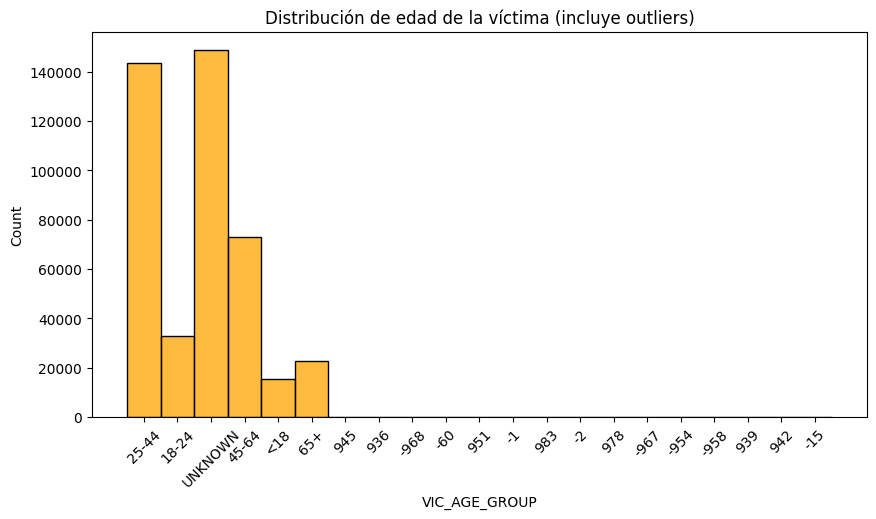

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df['VIC_AGE_GROUP'], kde=False, color='orange')
plt.title("Distribución de edad de la víctima (incluye outliers)")
plt.xticks(rotation=45)
plt.show()



In [23]:
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detectados")
    return outliers

detect_outliers('Latitude')
detect_outliers('Longitude')
detect_outliers('ADDR_PCT_CD')


Latitude: 0 outliers detectados
Longitude: 12263 outliers detectados
ADDR_PCT_CD: 0 outliers detectados


,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,JURISDICTION_CODE,JURIS_DESC,...,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column,day,hour


Columna 'duration_days' creada:
count    435645.000000
mean          9.322171
std         168.852560
min        -368.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       20102.000000
Name: duration_days, dtype: float64

Ejemplos de duración:
   CMPLNT_FR_DT CMPLNT_TO_DT  duration_days
0    2025-03-20   2025-03-14           -6.0
1    2025-01-02   2025-01-02            0.0
2    2025-03-05   2025-06-23          110.0
8    2025-09-17   2025-09-17            0.0
9    2025-04-03   2025-04-03            0.0
10   2025-09-16   2025-09-16            0.0
11   2025-04-05   2025-04-05            0.0
12   2025-07-09   2025-07-09            0.0
13   2025-08-09   2025-08-09            0.0
14   2025-07-19   2025-07-19            0.0


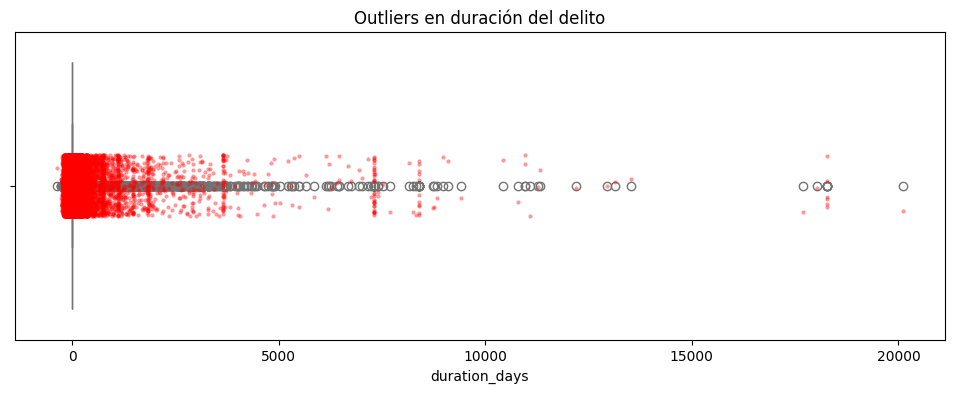

In [24]:


# creación columna día...aseguramos de que las fechas estén en formato datetime
df['CMPLNT_FR_DT'] = pd.to_datetime(df['CMPLNT_FR_DT'], errors='coerce')
df['CMPLNT_TO_DT'] = pd.to_datetime(df['CMPLNT_TO_DT'], errors='coerce')

# Calcular la duración en días
df['duration_days'] = (df['CMPLNT_TO_DT'] - df['CMPLNT_FR_DT']).dt.days

# Verificar
print("Columna 'duration_days' creada:")
print(df['duration_days'].describe())

# Ver ejemplos
print("\nEjemplos de duración:")
print(df[['CMPLNT_FR_DT', 'CMPLNT_TO_DT', 'duration_days']].head(10))



plt.figure(figsize=(12,4))
sns.boxplot(x=df['duration_days'], color='lightgreen')
sns.stripplot(x=df['duration_days'], color='red', size=3, alpha=0.4)
plt.title("Outliers en duración del delito")
plt.show()


Valores negativos o mayores a 365 días ---> errores.

Se imputan con la mediana (no influyen directamente en LAW_CAT_CD).


## 4 Tratamiento de outliers

In [25]:
#Outliers geográficos --> ELIMINACIÓN --> no aporta a nuestro target 
df = df[df['Latitude'].between(40.49, 40.92)]
df = df[df['Longitude'].between(-74.27, -73.68)]


In [26]:
# Edades → SEGMENTACIÓN (conserva información predictiva)
def segment_age(x):
    try:
        x = int(x)
        if x < 1 or x > 100:
            return "UNKNOWN"
        if x < 18:
            return "MINOR"
        if x < 65:
            return "ADULT"
        return "SENIOR"
    except:
        return "UNKNOWN"

df['VIC_AGE_SEG'] = df['VIC_AGE_GROUP'].apply(segment_age)
df['SUSP_AGE_SEG'] = df['SUSP_AGE_GROUP'].apply(segment_age)


In [27]:
# Duraciones anómalas --> IMPUTACIÓN (mediana)

median = df['duration_days'].median()
df.loc[df['duration_days'] < 0, 'duration_days'] = median
df.loc[df['duration_days'] > 365, 'duration_days'] = median



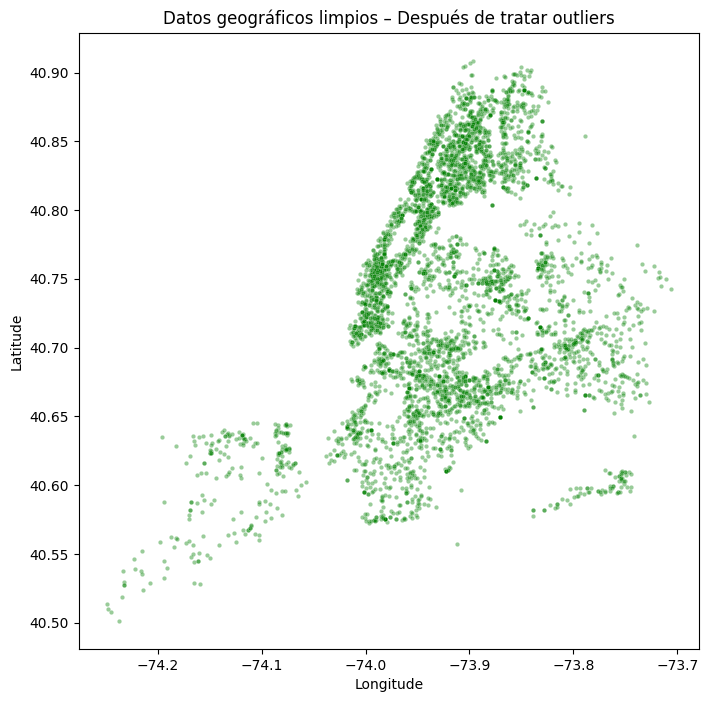

In [28]:
plt.figure(figsize=(8,8))
sns.scatterplot(
    data=df.sample(5000),
    x='Longitude', y='Latitude',
    s=10, alpha=0.4, color='green'
)
plt.title("Datos geográficos limpios – Después de tratar outliers")
plt.show()


## 5 Escalado

Se aplica StandardScaler a todas las variables numéricas para que trabajen en la misma escala y para asegurar que los modelos de clasificación supervisada (especialmente los basados en distancias) puedan aprender de forma equilibrada, evitar sesgos debidos a magnitudes diferentes y mejorar la convergencia.


In [34]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Define the target column
target_col = 'LAW_CAT_CD'

# Make a copy of the dataframe after all feature engineering (from `df`)
# to ensure all recent changes are included.
df_for_model = df.copy()

# Separate features (X) and target (y)
y = df_for_model[target_col]

# Columns to drop from the feature set
columns_to_exclude_from_X = [
    target_col,             # Target variable
    'CMPLNT_NUM',           # Identifier
    'CMPLNT_FR_DT', 'CMPLNT_FR_TM', 'CMPLNT_TO_DT', 'CMPLNT_TO_TM', 'RPT_DT', # Raw date/time, already processed into new features
    'Lat_Lon', 'New Georeferenced Column', 'X_COORD_CD', 'Y_COORD_CD', # Redundant geo-coordinates, Latitude/Longitude are kept
    'JURIS_DESC', 'PD_DESC', # Descriptive strings, numerical codes JURISDICTION_CODE/PD_CD are kept
    'VIC_AGE_GROUP', 'SUSP_AGE_GROUP' # Original age groups, segmented versions VIC_AGE_SEG/SUSP_AGE_SEG are kept
]

# Ensure we only drop columns that actually exist in the dataframe
columns_to_exclude_from_X = [col for col in columns_to_exclude_from_X if col in df_for_model.columns]

X = df_for_model.drop(columns=columns_to_exclude_from_X)

# --- Handle remaining NaNs and Infs in X before encoding and scaling (for X) ---
# Replace inf values with NaN for numerical columns first
for col in X.select_dtypes(include=['float64', 'int64']).columns:
    if (X[col] == np.inf).any() or (X[col] == -np.inf).any():
        X[col] = X[col].replace([np.inf, -np.inf], np.nan)

# Impute numerical columns with median (now including former inf values as NaN)
for col in X.select_dtypes(include=['float64', 'int64']).columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        if pd.isna(median_val): # If median itself is NaN (e.g., all values are NaN), fill with 0
            X[col] = X[col].fillna(0)
        else:
            X[col] = X[col].fillna(median_val)

# Impute categorical columns with mode
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].isnull().any():
        mode_val = X[col].mode()
        if not mode_val.empty:
            X[col] = X[col].fillna(mode_val[0])
        else: # If all values are NaN, mode will be empty, fill with 'UNKNOWN'
            X[col] = X[col].fillna('UNKNOWN')

# Perform one-hot encoding on these identified categorical columns
categorical_cols_to_encode_now = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols_to_encode_now, drop_first=True)

# Identify numerical columns for scaling after encoding (including dummy variables)
num_cols_encoded = X_encoded.select_dtypes(include=['float64', 'int64', 'uint8']).columns # uint8 for dummy variables

# --- Robust handling of NaNs/Infs in X_encoded BEFORE scaling ---
# Convert any inf values to NaN in numerical-like columns before scaling
for col in num_cols_encoded:
    if (X_encoded[col] == np.inf).any() or (X_encoded[col] == -np.inf).any():
        X_encoded[col] = X_encoded[col].replace([np.inf, -np.inf], np.nan)

# Impute any NaNs in numerical-like columns before scaling (e.g., if get_dummies produced NaNs from category NaNs with dummy_na=True, or if infs were converted to NaNs)
for col in num_cols_encoded:
    if X_encoded[col].isnull().any():
        median_val = X_encoded[col].median()
        if pd.isna(median_val): # If median itself is NaN (e.g., all values are NaN), fill with 0
            X_encoded[col] = X_encoded[col].fillna(0)
        else:
            X_encoded[col] = X_encoded[col].fillna(median_val)

# Now apply scaling, which should be safe as no NaNs/Infs are expected in num_cols_encoded
scaler = StandardScaler()
X_encoded[num_cols_encoded] = scaler.fit_transform(X_encoded[num_cols_encoded])

# --- Final verification after all steps ---
if X_encoded.isnull().sum().sum() > 0 or np.isinf(X_encoded.select_dtypes(include=np.number)).sum().sum() > 0:
    print("CRITICAL WARNING: NaNs or Infs still present in X_encoded after all processing. Details:")
    print(X_encoded.isnull().sum()[X_encoded.isnull().sum() > 0])
    print(np.isinf(X_encoded.select_dtypes(include=np.number)).sum()[np.isinf(X_encoded.select_dtypes(include=np.number)).sum() > 0])
else:
    print("ALL CLEAR: X_encoded is fully clean (no NaNs or Infs) and ready for model training.")


ALL CLEAR: X_encoded is fully clean (no NaNs or Infs) and ready for model training.


## 6 Feature engineering

In [ ]:
#Nuevos features creados:

#Día, hora ( para ayudar a detectar patrones temporales)
df['dayofweek'] = df['CMPLNT_FR_DT'].dt.dayofweek
df['month'] = df['CMPLNT_FR_DT'].dt.month

#indicador delito nocturno los delitos se concentran en horarios nocturnos?

#df['night'] = df['hour'].apply(lambda x: 1 if x>=20 or x<=5 else 0)

df['hour'] = pd.to_datetime(df['CMPLNT_FR_TM'], format="%H:%M:%S", errors='coerce').dt.hour.fillna(0)

df['night'] = df['hour'].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)


## 7 Codificación variables categoricas (One-Hot Encoding)

In [ ]:
cols_to_encode = [
    'BORO_NM', 
    'PREM_TYP_DESC', 
    'OFNS_DESC', 
    'SUSP_SEX', 
    'SUSP_RACE', 
    'LOC_OF_OCCUR_DESC'
]

df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
#Solo se codifican columnas que aportan información relevante para predecir LAW_CAT_CD.


## Discretizar hora en segmentos
df['hour_segment'] = pd.cut(df['hour'], bins=[-1,6,12,18,24],
                            labels=['Madrugada','Mañana','Tarde','Noche'])

# Discretizar duración del delito
df['duration_segment'] = pd.cut(df['duration_days'], bins=[-1,0,7,1000],
                                labels=['Corto','Medio','Largo'])

#Facilita que el modelo aprenda rangos significativos en lugar de valores exactos.
#Reduce la sensibilidad a outliers.

## Analisis balance de clases

In [ ]:


plt.figure(figsize=(6,4))
sns.countplot(x=y, palette='viridis')
plt.title("Balance antes de SMOTE")
plt.show()


Distribución original de clases:
   {'FELONY': np.int64(141223), 'MISDEMEANOR': np.int64(225967), 'VIOLATION': np.int64(68460)}
   Total muestras: 435650

División Train-Test completada:
   Train: 348520 muestras
   Test:  87130 muestras
   Distribución Train: Counter({np.int64(1): 180774, np.int64(0): 112978, np.int64(2): 54768})
   Distribución Test:  Counter({np.int64(1): 45193, np.int64(0): 28245, np.int64(2): 13692})

 ANÁLISIS Y BALANCE DE CLASES


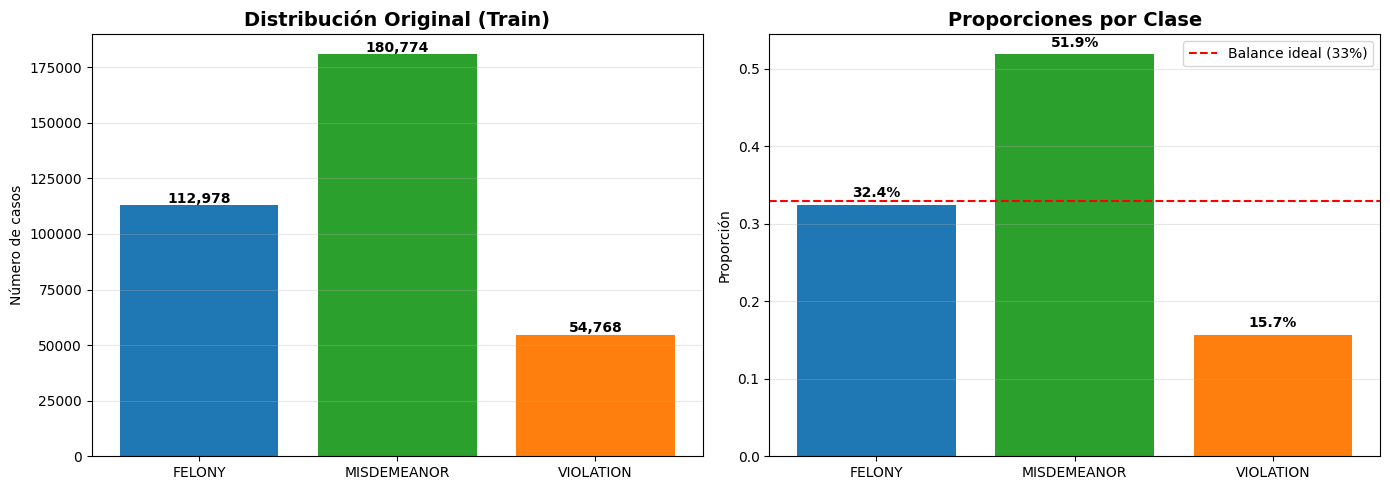


 Análisis de desbalance:
   Clase mayoritaria: MISDEMEANOR (180,774 casos)
   Clase minoritaria: VIOLATION (54,768 casos)
   Ratio de desbalance: 3.30:1

   Ratio > 2:1 → Se recomienda balance


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


# PREPARACIÓN DE DATOS 

# Separar features (X) y target (y)
target_col = 'LAW_CAT_CD'

le = LabelEncoder()
y_encoded = le.fit_transform(y_clean)  # FELONY=0, MISDEMEANOR=1, VIOLATION=2

print(f"\nDistribución original de clases:")
print(f"   {dict(zip(le.classes_, np.bincount(y_encoded)))}")
print(f"   Total muestras: {len(y_encoded)}")


#  DIVISIÓN TRAIN-TEST (ANTES DEL BALANCE)

#  Dividir antes de balancear para evitar data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_clean, 
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,  # Mantiene proporciones en train/test
    random_state=42
)

print(f"\nDivisión Train-Test completada:")
print(f"   Train: {X_train.shape[0]} muestras")
print(f"   Test:  {X_test.shape[0]} muestras")
print(f"   Distribución Train: {Counter(y_train)}")
print(f"   Distribución Test:  {Counter(y_test)}")


# BALANCE DE CLASES (SOLO EN TRAIN)


print("\n" + "="*80)
print(" ANÁLISIS Y BALANCE DE CLASES")
print("="*80)

# Visualizar desbalance inicial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Conteo absoluto
counts_train = Counter(y_train)
axes[0].bar([le.classes_[i] for i in counts_train.keys()], 
            counts_train.values(), 
            color=['#1f77b4', '#2ca02c', '#ff7f0e'])
axes[0].set_title('Distribución Original (Train)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Número de casos')
axes[0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(counts_train.items()):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Gráfico 2: Proporciones
props = [counts_train[i]/sum(counts_train.values()) for i in range(3)]
axes[1].bar([le.classes_[i] for i in counts_train.keys()], props,
            color=['#1f77b4', '#2ca02c', '#ff7f0e'])
axes[1].set_title('Proporciones por Clase', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Proporción')
axes[1].axhline(y=0.33, color='red', linestyle='--', label='Balance ideal (33%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, p in enumerate(props):
    axes[1].text(i, p + 0.01, f'{p:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('balance_original.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcular ratios de desbalance
max_count = max(counts_train.values())
min_count = min(counts_train.values())
imbalance_ratio = max_count / min_count

print(f"\n Análisis de desbalance:")
print(f"   Clase mayoritaria: {le.classes_[max(counts_train, key=counts_train.get)]} ({max_count:,} casos)")
print(f"   Clase minoritaria: {le.classes_[min(counts_train, key=counts_train.get)]} ({min_count:,} casos)")
print(f"   Ratio de desbalance: {imbalance_ratio:.2f}:1")
print(f"\n   Ratio > 2:1 → Se recomienda balance")

## SMOTE - Tomek

Es una tecnica hibrida que combina el sobremuestreo SMOTE (para generar datos sintéticos en la clase minoritaria) con el submuestreo Tomek Links (para limpiar el ruido y la superposición de clases) para mejorar la separación entre clases y el rendimiento del modelo. Funciona creando nuevas muestras minoritarias con SMOTE y luego eliminando pares de muestras (enlaces Tomek) de clases opuestas que son muy cercanas, limpiando así los límites de decisión y mejorando la capacidad del modelo para distinguir clases

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight


'''print("\n" + "-"*80)
print("APLICANDO: SMOTE-Tomek")
print("-"*80)

smt = SMOTETomek(random_state=42, n_jobs=-1)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

print(f" SMOTE-Tomek completado:")
print(f"   Antes:  {X_train.shape[0]} muestras")
print(f"   Después: {X_train_smt.shape[0]} muestras")
print(f"   Distribución balanceada: {Counter(y_train_smt)}")'''


# 1. Reducir dimensionalidad
print("Reduciendo dimensionalidad...")
selector = SelectKBest(mutual_info_classif, k=40)
X_train_reduced = selector.fit_transform(X_train, y_train)
X_test_reduced = selector.transform(X_test)

# 2. Calcular pesos (opcional, para ver los valores)
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
print(f"Class weights: {dict(zip(np.unique(y_train), class_weights))}")

# 3. Entrenar modelo CON PESOS (no necesitas balancear!)
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',  # ← Esto resuelve el desbalance
    random_state=42,
    n_jobs=-1
)

Reduciendo dimensionalidad...


NameError: name 'X_train' is not defined

## Graficos finales

C:\Users\pandr\AppData\Local\Temp\ipykernel_22628\2853395112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='LAW_CAT_CD', palette='viridis')


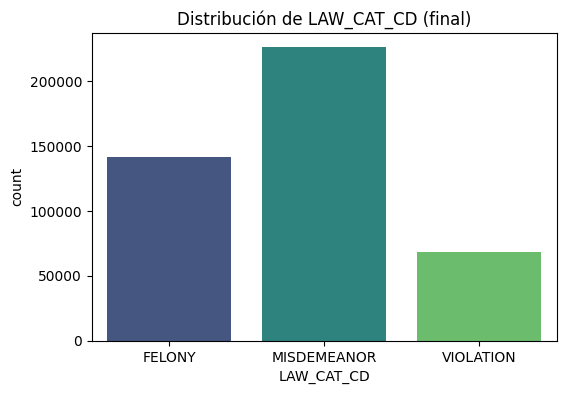

In [ ]:


plt.figure(figsize=(6,4))
sns.countplot(data=df, x='LAW_CAT_CD', palette='viridis')
plt.title("Distribución de LAW_CAT_CD (final)")
plt.show()



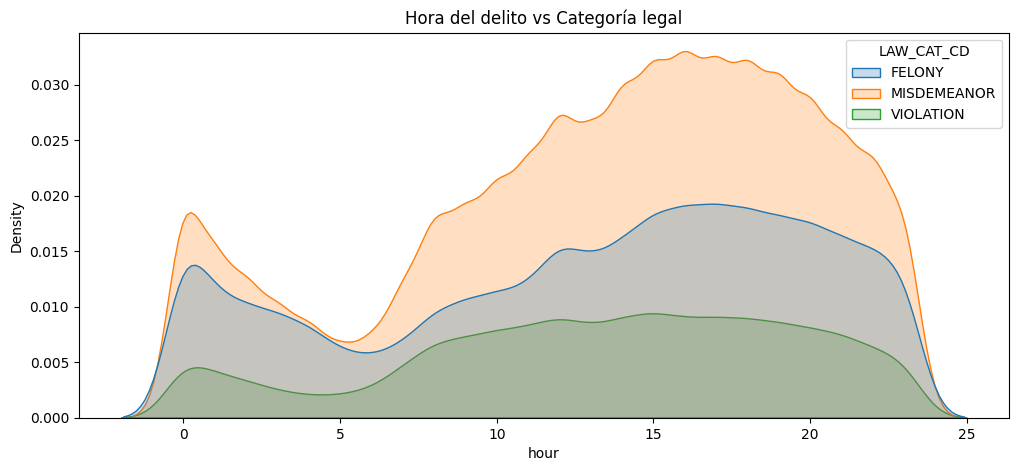

In [ ]:
plt.figure(figsize=(12,5))
sns.kdeplot(data=df, x='hour', hue='LAW_CAT_CD', fill=True)
plt.title("Hora del delito vs Categoría legal")
plt.show()


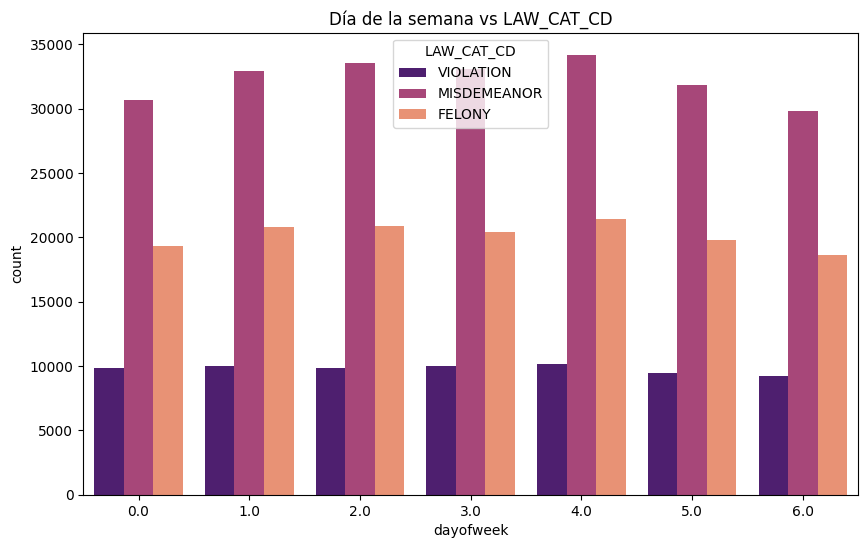

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='dayofweek', hue='LAW_CAT_CD', palette='magma')
plt.title("Día de la semana vs LAW_CAT_CD")
plt.show()


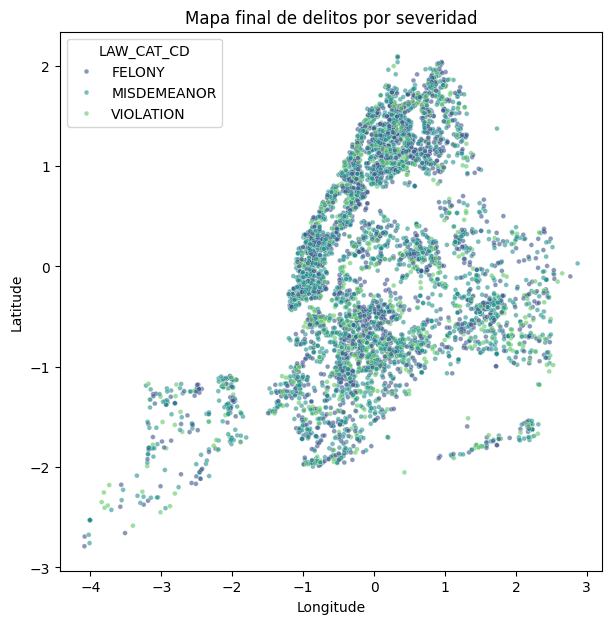

In [ ]:
plt.figure(figsize=(7,7))
sns.scatterplot(
    data=df.sample(6000),
    x='Longitude', y='Latitude',
    hue='LAW_CAT_CD',
    palette='viridis',
    s=12, alpha=0.6
)
plt.title("Mapa final de delitos por severidad")
plt.show()


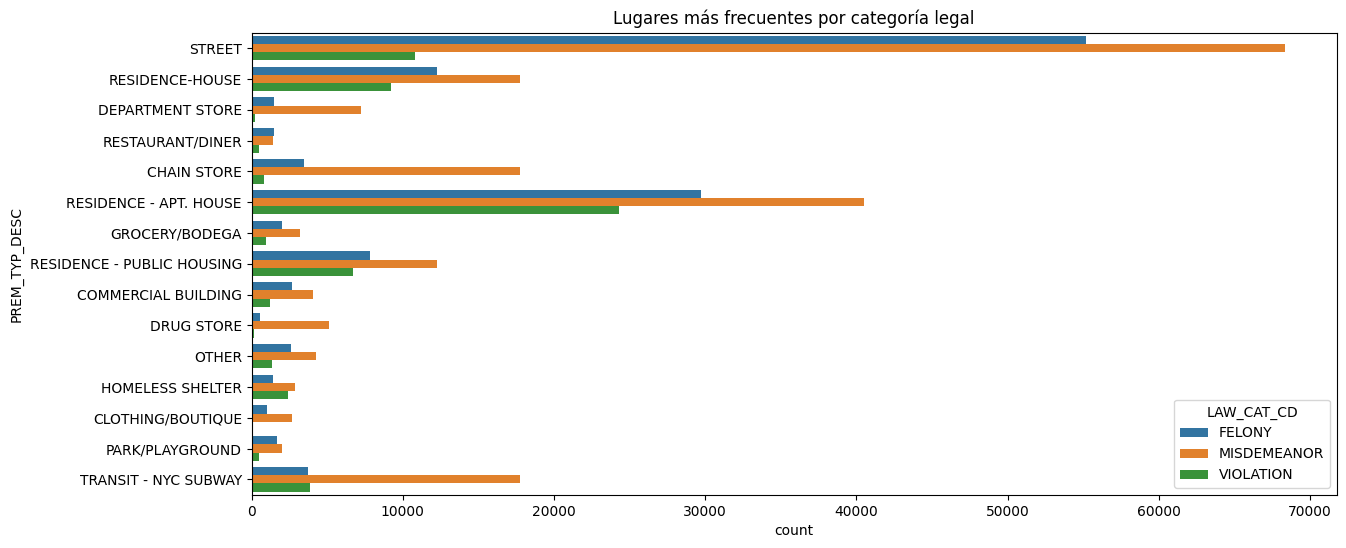

In [ ]:
plt.figure(figsize=(14,6))
top_premises = df['PREM_TYP_DESC'].value_counts().index[:15]
sns.countplot(data=df[df['PREM_TYP_DESC'].isin(top_premises)],
              y='PREM_TYP_DESC', hue='LAW_CAT_CD')
plt.title("Lugares más frecuentes por categoría legal")
plt.show()
